## Model development for Legacy model
- Pre-trained word embeddings

In [1]:
!pip install nltk
!pip install matplotlib

You should consider upgrading via the '/usr/local/bin/python3.7 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/local/bin/python3.7 -m pip install --upgrade pip' command.


In [2]:
from build_model import *

# features = feature_extractions("Flickr8k_Dataset")

# #save features for future use.
# with open("features.pkl", "wb") as f:
#    dump(features, f)

In [3]:
with open("Flickr8k_text/Flickr8k.token.txt", "r") as f:
    raw_caption = f.read()

caption_dict = caption_dictionary(raw_caption)
caption_dict = caption_cleaning(caption_dict)

#Save the caption_dict for future use
with open("captions.pkl", "wb") as f:
    dump(caption_dict, f)

In [4]:
train = dataset("Flickr8k_text/Flickr_8k.trainImages.txt")
dev = dataset("Flickr8k_text/Flickr_8k.devImages.txt")
test = dataset("Flickr8k_text/Flickr_8k.testImages.txt")

train_caption_dict = load_captions(train, 1)
train_features = load_features(train)
dev_caption_dict = load_captions(dev, 1)
dev_features = load_features(dev)
test_caption_dict = load_captions(test, 0)
test_features = load_features(test)

#Initialize the tokenizer
vocab_size = 3001
tokenizer = create_tokenizer(train_caption_dict, num_vocab=vocab_size)

#Save the tokenizer for caption_generation
with open("../tokenizer.json", "w") as f:
    json.dump(tokenizer.to_json(), f)

print("vocab size: {}".format(vocab_size))
max_length = max([len(c.split()) for c in caption_to_list(train_caption_dict)]) - 1 #Maximum length of input sequence
print("max length: {}".format(max_length))

vocab size: 3001
max length: 37


In [5]:
path_to_glove_file = "./glove.6B/glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

#Initialize embedding matrix
embed_dim = 100
embedding_matrix = np.zeros((vocab_size, embed_dim))
coverage = set()
for i in range(1, vocab_size):
    w = tokenizer.index_word[i]
    if w in embeddings_index.keys():
        embedding_matrix[i] = embeddings_index.get(w) #use the pre-trained embeddings, set 0 otherwise
        coverage.add(w)

oov = check_coverage(tokenizer, coverage, vocab_size=vocab_size)
print(oov)

Coverage in vocab: 0.9866711096301233
Coverage in word_count: 0.8398431905107979
{'<startseq>': 30000, '<endseq>': 30000, 'tshirt': 125, 'snowcovered': 36, 'rollerblader': 16, 'merrygoround': 13, 'upsidedown': 12, 'waterskier': 10, 'floaties': 10, 'tshirts': 8, 'africanamerican': 8, 'bicycler': 8, 'tugofwar': 7, 'outstreached': 7, 'offcamera': 7, 'darkskinned': 7, 'brownhaired': 7, 'darkhaired': 6, 'hulahoops': 6, 'wakeboarder': 6, 'midjump': 6, 'treelined': 5, 'threewheeled': 5, 'hiviz': 5, 'wakeboards': 5, 'corndogs': 5, 'somthing': 4, 'blackandwhite': 4, 'dalmation': 4, 'facepaint': 4, 'plushie': 4, 'grayhaired': 4, 'fourwheeler': 4, 'fencedin': 4, 'lightcolored': 4, 'surfboarder': 4, 'redhaired': 4, 'stripy': 4, 'longnecked': 4}


Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 4096)]       0                                            
__________________________________________________________________________________________________
dropout (Dropout)               (None, 4096)         0           input_1[0][0]                    
__________________________________________________________________________________________________
dense (Dense)                   (None, 64)           262208      dropout[0][0]                    
__________________________________________________________________________________________________
input_2 (InputLaye

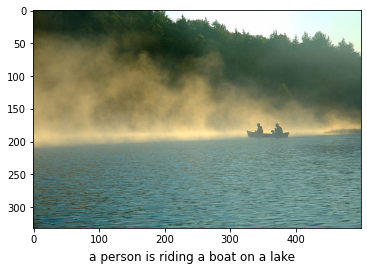

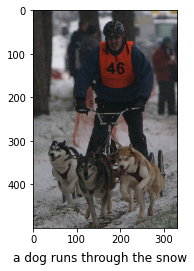

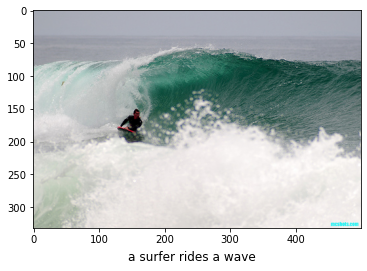

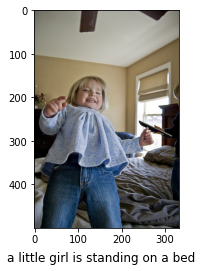

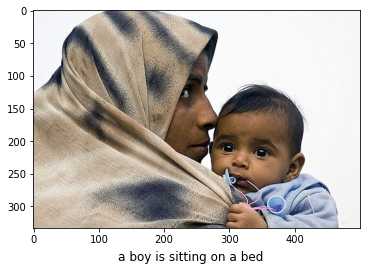

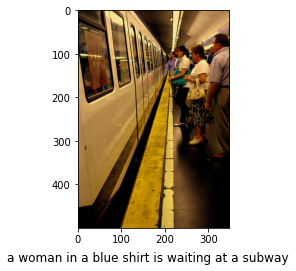

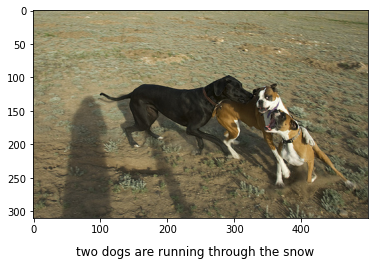

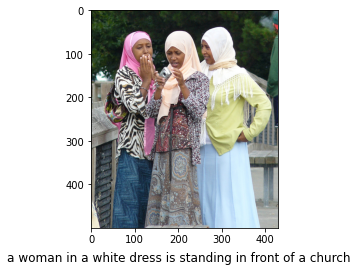

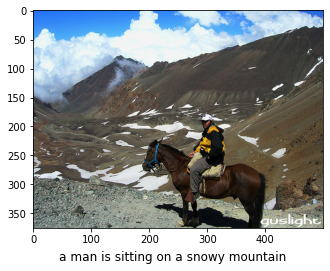

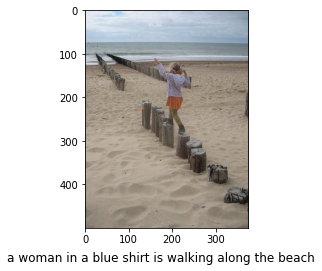

In [6]:
%%time
num_epoches = 10
num_photos = 32 #photos per batch

steps_per_epoch = int(len(train_caption_dict) / num_photos)
val_steps = int(len(dev_caption_dict) / num_photos)

model = define_model(max_length, vocab_size, dp_rate=0.1, embed_size=embed_dim, embedding_matrix=embedding_matrix)

train_generator = generate_dataset(train_caption_dict, train_features, tokenizer, max_length, vocab_size, num_photos)
dev_generator = generate_dataset(dev_caption_dict, dev_features, tokenizer, max_length, vocab_size, num_photos)

for i in range(num_epoches):
    for step in range(5*steps_per_epoch):
        X, Y = next(train_generator)
        model.train_on_batch(X, Y)
    
    model.save("../model/model_v{i}.h5".format(i=i))
    print("finish saving model: model_v{i}".format(i=i))
    
evaluate_model(model, tokenizer, test_caption_dict, test_features, max_length, vocab_size)

In [7]:
##Check model weights on embedding
model.get_layer('text_embedding').get_weights()[0] - embedding_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Fine-tuning

finish saving model: model_v10
finish saving model: model_v11
finish saving model: model_v12
finish saving model: model_v13
finish saving model: model_v14
BLEU Score on Test Set: 0.56, 0.38, 0.28, 0.16
CPU times: user 14min 32s, sys: 1min 17s, total: 15min 50s
Wall time: 8min 53s


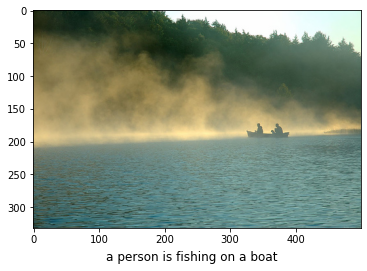

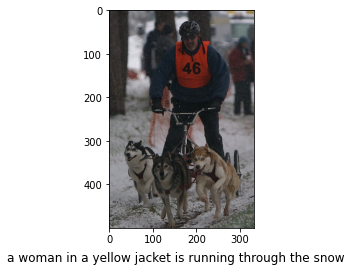

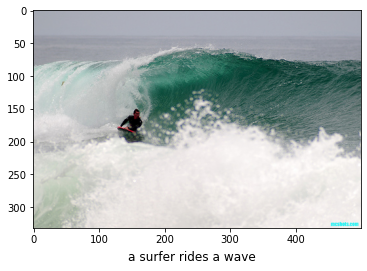

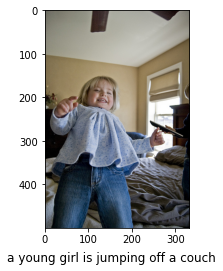

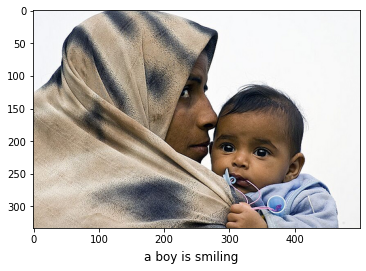

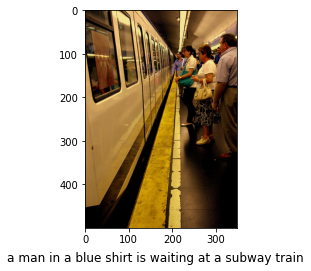

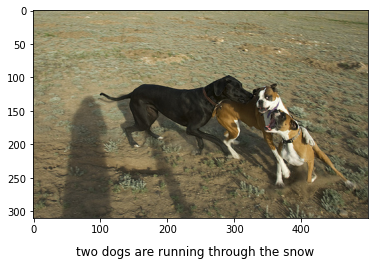

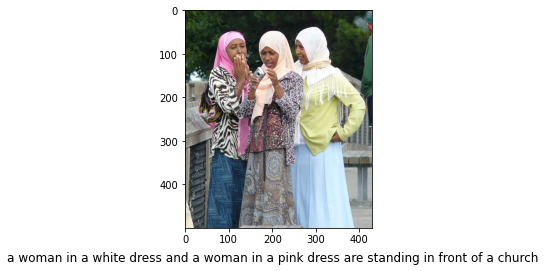

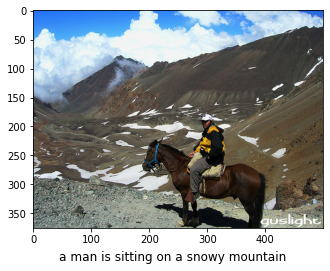

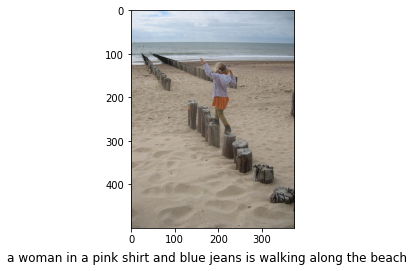

In [8]:
%%time
model.get_layer('text_embedding').trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

for i in range(5):
    for step in range(5*steps_per_epoch):
        X, Y = next(train_generator)
        model.train_on_batch(X, Y)
    
    model.save("../model/model_v{i}.h5".format(i=i+num_epoches))
    print("finish saving model: model_v{i}".format(i=i+num_epoches))
    
evaluate_model(model, tokenizer, test_caption_dict, test_features, max_length, vocab_size)

In [11]:
##Check model weights on embedding
model.get_layer('text_embedding').get_weights()[0] - embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.00300372, -0.00220583, -0.01509613, ...,  0.01197872,
        -0.00468338, -0.0030098 ],
       [ 0.01633984, -0.0054246 , -0.01203715, ...,  0.00331263,
         0.0007342 , -0.0095675 ],
       ...,
       [ 0.00567067,  0.00843706, -0.00652075, ...,  0.01121944,
        -0.01284666, -0.00648504],
       [ 0.00424742,  0.00111675, -0.0154238 , ..., -0.00203761,
        -0.00195277, -0.00449924],
       [ 0.01856819,  0.00339556,  0.01823628, ..., -0.01426876,
         0.01323956,  0.01308912]])

## Evaluate on certain snapshots of model

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


...

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


BLEU Score on Test Set: 0.39, 0.25, 0.18, 0.09


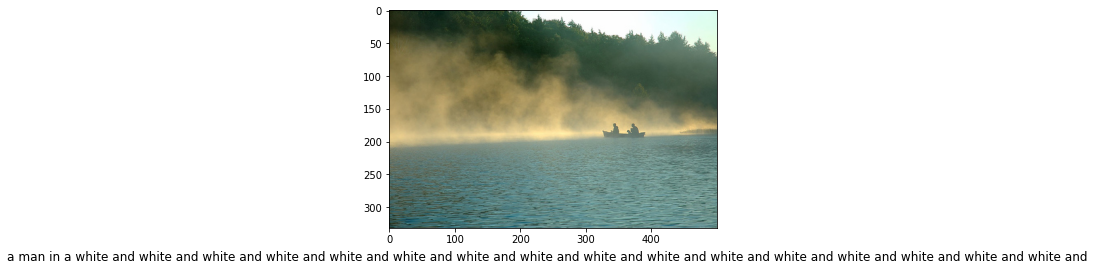

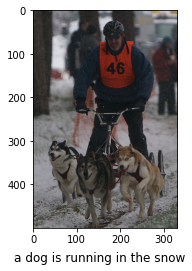

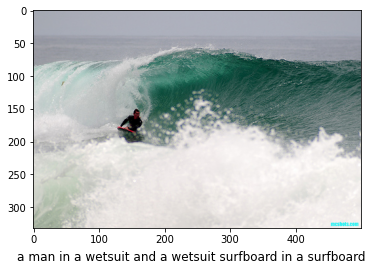

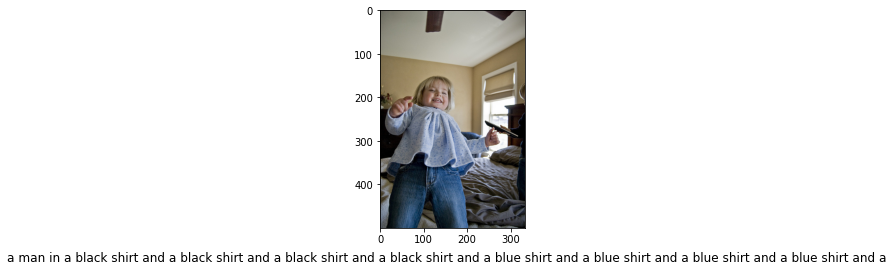

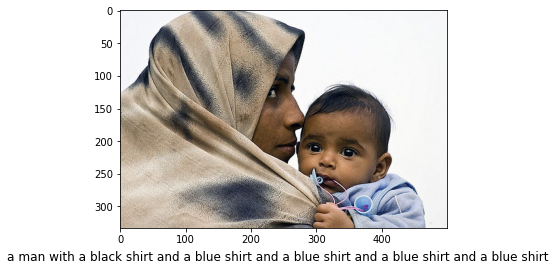

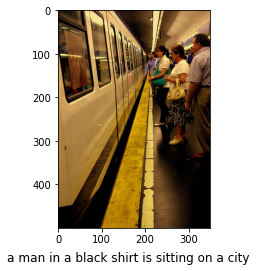

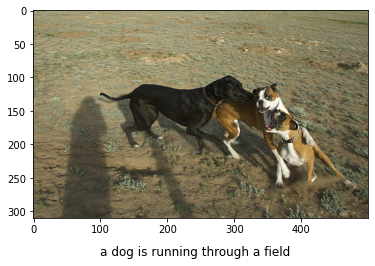

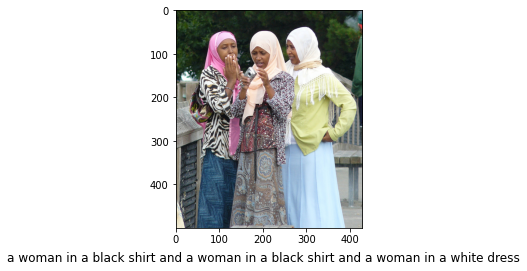

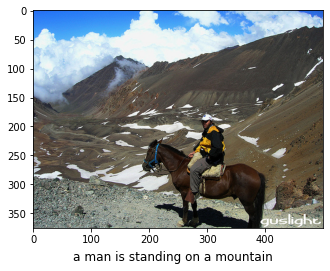

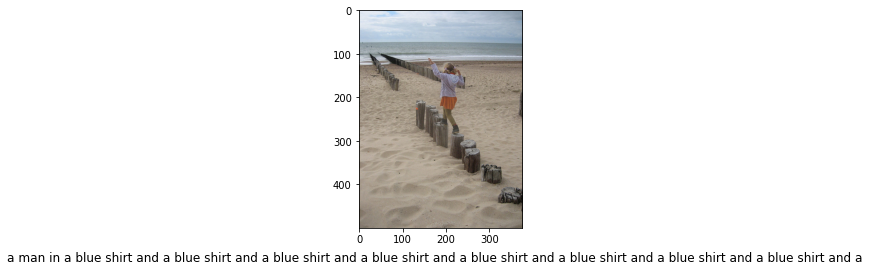

In [9]:
#Trained at early stage
model_checkpoint = keras.models.load_model("../model/model_v{i}.h5".format(i=0))
evaluate_model(model_checkpoint, tokenizer, test_caption_dict, test_features, max_length, vocab_size)

BLEU Score on Test Set: 0.56, 0.38, 0.28, 0.16


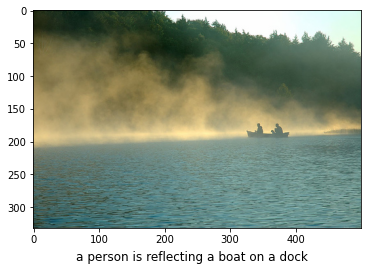

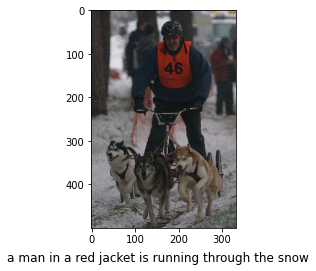

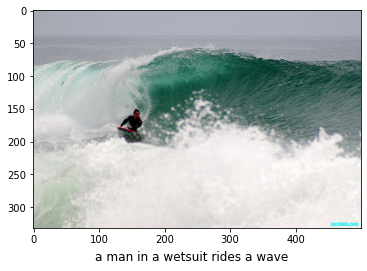

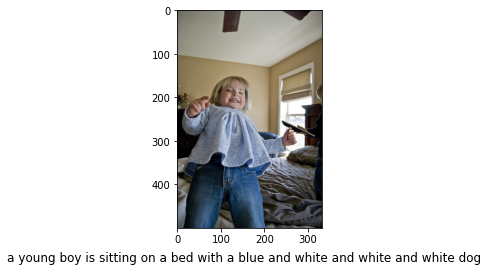

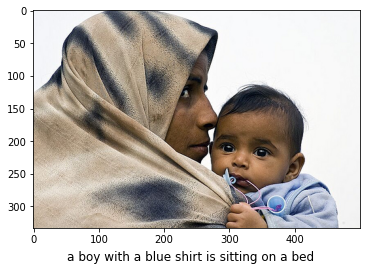

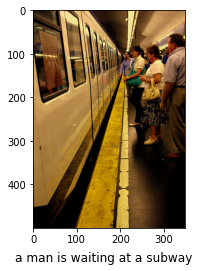

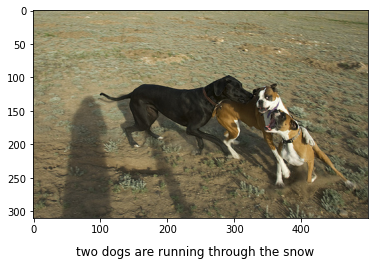

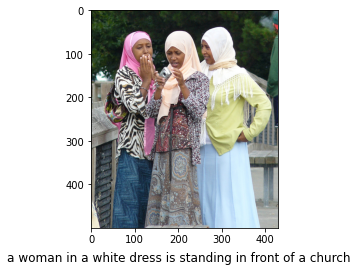

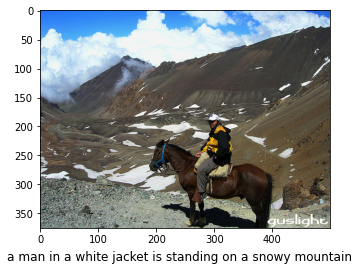

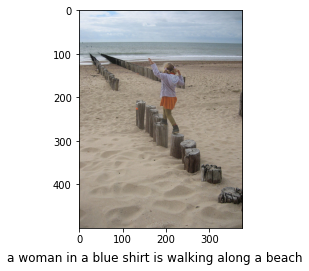

In [12]:
#Trained at early stage
model_checkpoint = keras.models.load_model("../model/model_v{i}.h5".format(i=5))
evaluate_model(model_checkpoint, tokenizer, test_caption_dict, test_features, max_length, vocab_size)

BLEU Score on Test Set: 0.55, 0.37, 0.28, 0.15


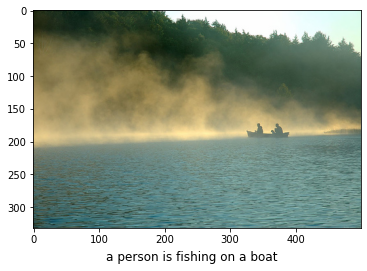

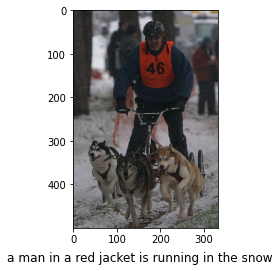

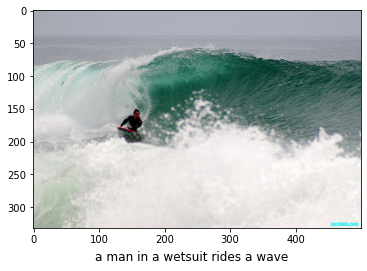

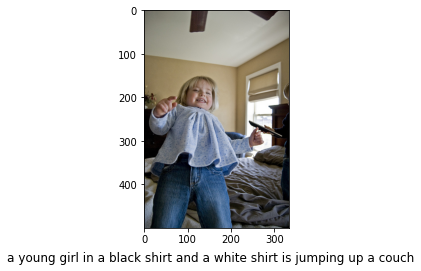

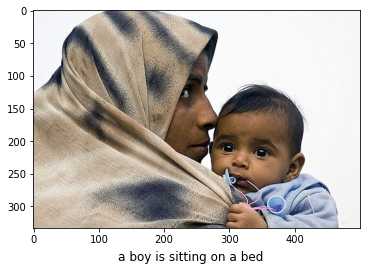

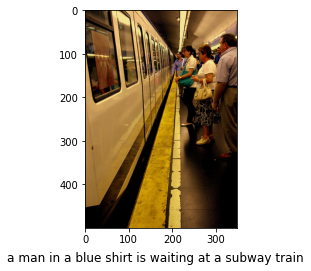

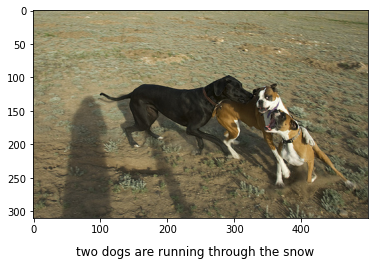

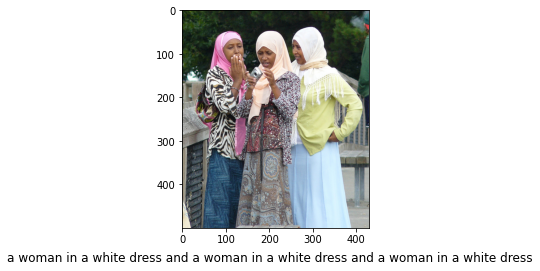

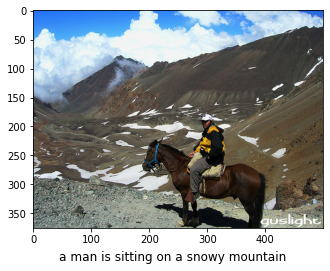

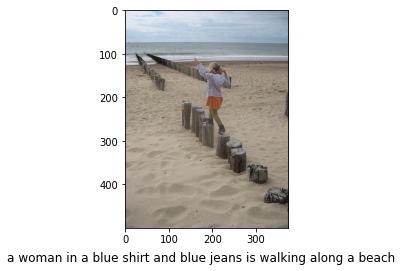

In [10]:
#Trained at first fine-tuning stage
model_checkpoint = keras.models.load_model("../model/model_v{i}.h5".format(i=10))
evaluate_model(model_checkpoint, tokenizer, test_caption_dict, test_features, max_length, vocab_size)